In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
tf.random.set_seed(SEED)

In [5]:
# Load data 
BASE_DIR = "../data"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
VAL_DIR = os.path.join(BASE_DIR, "Validation")
TEST_DIR = os.path.join(BASE_DIR, "Test")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    color_mode="rgb",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    color_mode="rgb",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    color_mode="rgb",
    shuffle=False
)

class_names = train_ds.class_names
print(class_names)

Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.
['WithMask', 'WithoutMask']


In [7]:
#preprocessing
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [8]:
#model building
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name="data_augmentation")

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./127.5, offset=-1),  # preprocessing: [0,255] -> [-1,1] for MobileNetV2
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

In [ ]:
#head-training
base_model.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
history_head = model.fit(train_ds, validation_data=val_ds, epochs=10)

In [9]:
#fine tuning and saving
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="binary_crossentropy",
              metrics=["accuracy"])

os.makedirs("../models", exist_ok=True)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "../models/facemask_mobilenetv2_best.keras",
        monitor="val_loss", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True),
]

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

model.save("../models/facemask_mobilenetv2.keras")

Epoch 1/50


c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 399ms/step - accuracy: 0.8659 - loss: 0.3139 - val_accuracy: 0.9100 - val_loss: 0.2199
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 114s 364ms/step - accuracy: 0.9649 - loss: 0.1035 - val_accuracy: 0.9700 - val_loss: 0.0775
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 109s 349ms/step - accuracy: 0.9768 - loss: 0.0672 - val_accuracy: 0.9887 - val_loss: 0.0370
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 115s 366ms/step - accuracy: 0.9796 - loss: 0.0595 - val_accuracy: 0.9950 - val_loss: 0.0158
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 108s 345ms/step - accuracy: 0.9816 - loss: 0.0500 - val_accuracy: 0.9987 - val_loss: 0.0087
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 106s 340ms/step - accuracy: 0.9856 - loss: 0.0425 - val_accuracy: 0.9987 - val_loss: 0.0060
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 109s 347ms/step - accuracy: 0.9880 - loss: 0.0348 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 109s 348ms/step - accuracy: 0.9894 - loss: 0.03

In [10]:
# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")

y_true = np.concatenate([y.numpy() for _, y in test_ds]).flatten().astype(int)
y_pred = (model.predict(test_ds) >= 0.5).astype(int).flatten()
print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 267ms/step - accuracy: 0.9980 - loss: 0.0048
Test accuracy: 0.9980
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step
              precision    recall  f1-score   support

    WithMask       1.00      1.00      1.00       483
 WithoutMask       1.00      1.00      1.00       509

    accuracy                           1.00       992
   macro avg       1.00      1.00      1.00       992
weighted avg       1.00      1.00      1.00       992

[[482   1]
 [  1 508]]


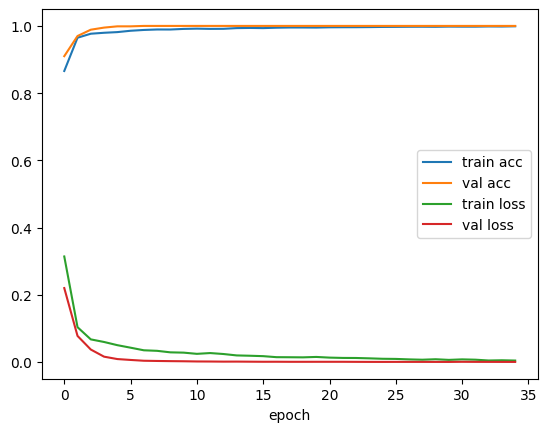

In [11]:
import matplotlib.pyplot as plt
h = history_finetune.history
plt.plot(h["accuracy"], label="train acc"); plt.plot(h["val_accuracy"], label="val acc")
plt.plot(h["loss"], label="train loss"); plt.plot(h["val_loss"], label="val loss")
plt.legend(); plt.xlabel("epoch"); plt.savefig("../reports/training_curves.png", dpi=200)